In [41]:
import pandas as pd                         # Pandas
import seaborn as sns                       # Seaborn 시각화 라이브러리 
import matplotlib.pyplot as plt             # Matplotlib 시각화 라이브러리
import numpy as np                          # Numpy 
from sklearn.linear_model import LogisticRegression         # 로지스틱 회귀분석
import statsmodels.api as sm               # 통계분석
from sklearn.model_selection import train_test_split  # 데이터 분할
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # 모델 평가 지표

In [42]:
autoMpg = pd.read_csv('auto-mpg.csv')        # auto-mpg.csv 파일을 읽어서 autoMpg 변수에 저장
autoMpg.head()                               # autoMpg 데이터프레임의 상위 5

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [43]:
# 결측치 제거
autoMpg["horsepower"] = autoMpg["horsepower"].replace("?", np.nan)  # "?"를 NaN으로 변환
autoMpg["horsepower"] = autoMpg["horsepower"].astype(float)  # horsepower 열을 float 타입으로 변환
autoMpg["horsepower"].fillna(autoMpg["horsepower"].mean(), inplace=True)  # 결측치를 평균값으로 대체


#autoMpg.dropna(subset=["mpg"], inplace=True)  # mpg 열의 결측치가 있는 행 제거
#autoMpg.reset_index(drop=True, inplace=True) 

C:\Users\CSE\AppData\Local\Temp\ipykernel_20472\2557229438.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  autoMpg["horsepower"].fillna(autoMpg["horsepower"].mean(), inplace=True)  # 결측치를 평균값으로 대체


In [44]:
print(autoMpg.isnull().sum())  # 각 열의 결측치 개수 출력


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


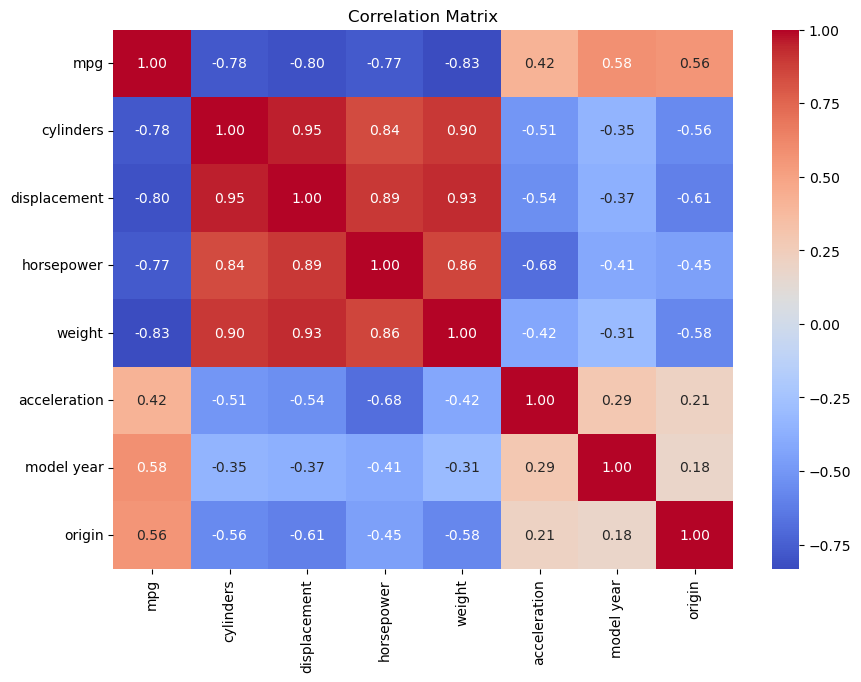

In [45]:
# 상관관계
plt.figure(figsize=(10, 7))
sns.heatmap(autoMpg.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

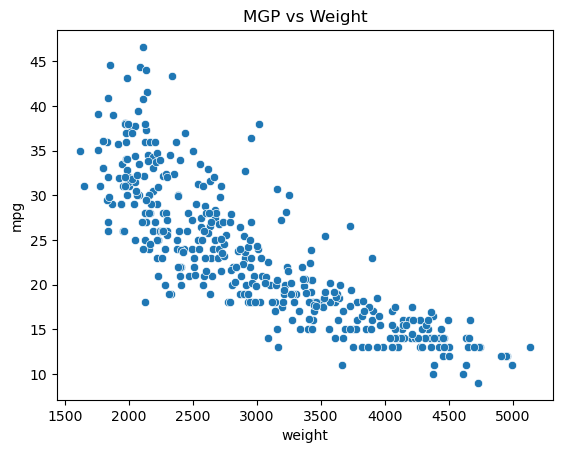

In [46]:
sns.scatterplot(x = "weight", y = "mpg", data = autoMpg)
plt.title("MGP vs Weight")
plt.show()

In [47]:
# 선형회귀 분석
X = autoMpg[["horsepower"]] # 독립 변수
y = autoMpg["mpg"]          # 종속 변수

x = sm.add_constant(X)      # 상수항 추가
model = sm.OLS(y, x).fit()  # OLS 회귀 모델 적합
print(model.summary())      # 회귀 분석 결과 출력


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     582.1
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           9.26e-80
Time:                        15:47:58   Log-Likelihood:                -1202.7
No. Observations:                 398   AIC:                             2409.
Df Residuals:                     396   BIC:                             2417.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.0045      0.728     54.978      0.0

In [48]:
# 다중선형회귀 분석
X_multi = autoMpg[["cylinders", "displacement", "horsepower", "weight", "acceleration", "model year", "origin"]]
X_multi = sm.add_constant(X_multi)  # 상수항 추가
model_multi = sm.OLS(y, X_multi).fit()  # OLS 회귀 모델 적합
print(model_multi.summary())  # 회귀 분석 결과 출력

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     255.4
Date:                Tue, 30 Sep 2025   Prob (F-statistic):          2.25e-141
Time:                        15:47:58   Log-Likelihood:                -1040.3
No. Observations:                 398   AIC:                             2097.
Df Residuals:                     390   BIC:                             2129.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -18.0587      4.583     -3.940   

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)
model_train = sm.OLS(y_train, X_train).fit()
y_pred = model_train.predict(X_test)

print("R2: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MAPE: ", np.mean(np.abs((y_test - y_pred) / y_test)) * 100, "%")

# 다중 공산성 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_multi.drop('const', axis=1)

vif = pd.DataFrame()
vif["feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif)



R2:  0.8475731044779423
MSE:  8.19545210407384
RMSE:  2.8627700054446987
MAE:  2.253388405931761
MAPE:  11.42899318872017 %
        feature         VIF
0     cylinders  116.884348
1  displacement   96.613223
2    horsepower   62.581567
3        weight  136.000319
4  acceleration   67.455568
5    model year  115.446570
6        origin    8.278726


In [50]:
#weight_reduced = X_multi.drop(['weight'], axis=1)
#weight_modelyear_reduced = X_multi.drop(['weight', 'model year'], axis=1)
# => 결과 R2가 0.7053

x_multimodel_reduced = sm.add_constant(autoMpg[["weight", "model year", "horsepower", "cylinders","origin", "displacement"]])
# => weight, model year 만 사용한 결과 R2가 0.82441546
# => MSE: 0.803
# => RMSE: 0.802
# 
X_vif_reduced = x_multimodel_reduced.drop('const', axis=1)
vif_reduced = pd.DataFrame()
vif_reduced["feature"] = X_vif_reduced.columns
vif_reduced["VIF"] = [variance_inflation_factor(X_vif_reduced.values, i) for i in range(X_vif_reduced.shape[1])]

print(vif_reduced)

        feature         VIF
0        weight  110.205139
1    model year   53.546650
2    horsepower   46.742523
3     cylinders  116.706639
4        origin    8.267194
5  displacement   93.965623


In [51]:
X_train, X_test, y_train, y_test = train_test_split(x_multimodel_reduced, y, test_size=0.2, random_state=42)
model_reduced = sm.OLS(y_train, X_train).fit()
y_pred2 = model_reduced.predict(X_test)
print("R2: ", r2_score(y_test, y_pred2))
print(model_reduced.summary())

R2:  0.8461978854244889
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     226.4
Date:                Tue, 30 Sep 2025   Prob (F-statistic):          2.76e-110
Time:                        15:47:58   Log-Likelihood:                -842.05
No. Observations:                 318   AIC:                             1698.
Df Residuals:                     311   BIC:                             1724.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -19.2206 

In [52]:
#autoMpg.columns = [c.strip().lower().replace(" ", "_") for c in autoMpg.columns]  # 열 이름을 소문자 및 밑줄로 변환
#autoMpg['horsepower'] = autoMpg.to_numeric(autoMpg['horsepower'], errors='coerce')  # horsepower 열을 숫자형으로 변환
#autoMpg = autoMpg[['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year','origin']].dropna()

In [53]:
autoMpg_train = autoMpg.sample(frac=0.8, random_state=42)  # 80%를 훈련 데이터로 사용
autoMpg_test = autoMpg.drop(autoMpg_train.index)  # 나머
 
X_cols = [c for c in autoMpg.columns if c != "mpg"]
X_train = autoMpg_train[X_cols].reset_index(drop=True)
X_test  = autoMpg_test[X_cols].reset_index(drop=True)
y_train = autoMpg_train["mpg"].reset_index(drop=True)
y_test  = autoMpg_test["mpg"].reset_index(drop=True)


In [54]:
autoMpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [57]:
X_train_num = X_train.drop(['car name'], axis=1)
X_test_num  = X_test.drop(['car name'], axis=1)

# 표준화
X_train_std = (X_train_num - X_train_num.mean()) / X_train_num.std(ddof=0)
X_test_std  = (X_test_num - X_train_num.mean()) / X_train_num.std(ddof=0)


X_train_std.columns = [f"{c}_std" for c in X_train_num.columns]
X_test_std.columns  = [f"{c}_std" for c in X_test_num.columns]

# (b) 로그 변환 (음수 방지용 clip)
X_train_log = np.log1p(X_train_num.clip(lower=0))
X_test_log  = np.log1p(X_test_num.clip(lower=0))
X_train_log.columns = [f"{c}_log" for c in X_train_log.columns]
X_test_log.columns  = [f"{c}_log" for c in X_test_log.columns]

# Min-Max Scaling
xmin = X_train_num.min()
xmax = X_train_num.max()
X_train_mm = (X_train_num - xmin) / (xmax - xmin).replace(0, np.nan)
X_test_mm  = (X_test_num - xmin) / (xmax - xmin).replace(0, np.nan)
X_train_mm = X_train_mm.fillna(0.0)
X_test_mm  = X_test_mm.fillna(0.0)
X_train_mm.columns = [f"{c}_mm" for c in X_train_mm.columns]
X_test_mm.columns  = [f"{c}_mm" for c in X_test_mm.columns]

In [61]:
# (d) 제곱항(Polynomial features)
X_train_sq = X_train_num ** 2
X_test_sq = X_test_num ** 2
X_train_sq.columns = [f"{c}_sq" for c in X_train_sq.columns]
X_test_sq.columns  = [f"{c}_sq" for c in X_test_sq.columns]

In [63]:
X_train_all = pd.concat([X_train.reset_index(drop=True),
                         X_train_std.reset_index(drop=True),
                         X_train_log.reset_index(drop=True),
                         X_train_mm.reset_index(drop=True),
                         X_train_sq.reset_index(drop=True)], axis=1)

X_test_all = pd.concat([X_test.reset_index(drop=True),
                        X_test_std.reset_index(drop=True),
                        X_test_log.reset_index(drop=True),
                        X_test_mm.reset_index(drop=True),
                        X_test_sq.reset_index(drop=True)], axis=1)

print("원본 특성 수:", len(X_cols))
print("확장된 특성 수:", X_train_all.shape[1])

# 5) 선형회귀 (statsmodels OLS)
X_train_sm = sm.add_constant(X_train_all)
X_test_sm  = sm.add_constant(X_test_all, has_constant="add")

원본 특성 수: 8
확장된 특성 수: 35


In [64]:
X_train_sm

,const,cylinders,displacement,horsepower,weight,model year,origin,cylinders_std,displacement_std,horsepower_std,...,acceleration_mm,model year_mm,origin_mm,cylinders_sq,displacement_sq,horsepower_sq,weight_sq,acceleration_sq,model year_sq,origin_sq
0,1.0,8,304.0,150.0,3433,70,1,-0.871909,-0.986120,-1.318561,...,0.559524,0.500000,1.0,16,8281.0,2809.0,3222025,302.76,5776,9
1,1.0,4,97.0,88.0,2130,70,3,-0.871909,-0.711377,-0.655364,...,0.630952,1.000000,0.0,16,14400.0,6241.0,6890625,345.96,6724,1
2,1.0,4,91.0,68.0,2025,82,3,0.300468,0.349700,-0.119705,...,0.297619,0.083333,0.0,36,53824.0,10000.0,6937956,169.00,5041,1
3,1.0,4,91.0,60.0,1800,78,3,1.472844,1.164456,1.155674,...,0.309524,0.500000,0.0,64,101124.0,22500.0,15523600,174.24,5776,1
4,1.0,4,115.0,95.0,2694,75,2,1.472844,1.164456,1.155674,...,0.386905,0.250000,0.0,64,101124.0,22500.0,17952169,210.25,5329,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,1.0,3,70.0,97.0,2330,72,3,-0.871909,-1.033489,-1.012470,...,0.589286,0.833333,1.0,16,7396.0,4225.0,4452100,320.41,6400,9
314,1.0,8,350.0,180.0,4499,73,1,-0.871909,-0.919803,-0.935947,...,0.625000,0.583333,1.0,16,9604.0,4624.0,4182025,342.25,5929,9
315,1.0,4,134.0,95.0,2515,78,3,-0.871909,-0.919803,-0.935947,...,0.511905,0.666667,1.0,16,9604.0,4624.0,4558225,275.56,6084,9
316,1.0,4,89.0,62.0,2050,81,3,-0.871909,-0.787168,-0.425796,...,0.630952,1.000000,0.0,16,12544.0,7744.0,6969600,345.96,6724,1


In [60]:
# 표준화 이후의 성능
x_multimodel_reduced = sm.add_constant(autoMpg[["cylinders", "displacement", "horsepower", "weight","model year", "origin"]])

X_train, X_test, y_train, y_test = train_test_split(x_multimodel_reduced, y, test_size=0.2, random_state=42)
model_reduced = sm.OLS(y_train, X_train).fit()
y_pred2 = model_reduced.predict(X_test)
print("R2: ", r2_score(y_test, y_pred2))
print(model_reduced.summary())

R2:  0.8461978854244886
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     226.4
Date:                Tue, 30 Sep 2025   Prob (F-statistic):          2.76e-110
Time:                        15:53:25   Log-Likelihood:                -842.05
No. Observations:                 318   AIC:                             1698.
Df Residuals:                     311   BIC:                             1724.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -19.2206 

In [ ]:
# 사용할 변수 목록 (car name은 제외, 숫자형만)
#feature_list = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']

feature_list = ['cylinders', 'displacement', 'horsepower', 'weight', 'model year', 'origin']
results = []

for feature in feature_list:

    X_train_f = X_train[[feature]]
    X_test_f  = X_test[[feature]]

    # 표준화
    X_train_std_f = (X_train_f - X_train_f.mean()) / X_train_f.std(ddof=0)
    X_test_std_f  = (X_test_f - X_train_f.mean()) / X_train_f.std(ddof=0)

    # 로그 변환
    X_train_log_f = np.log1p(X_train_f.clip(lower=0))
    X_test_log_f  = np.log1p(X_test_f.clip(lower=0))

    # MinMax
    xmin = X_train_f.min()
    xmax = X_train_f.max()
    X_train_mm_f = (X_train_f - xmin) / (xmax - xmin).replace(0, np.nan)
    X_test_mm_f  = (X_test_f - xmin) / (xmax - xmin).replace(0, np.nan)
    X_train_mm_f = X_train_mm_f.fillna(0.0)
    X_test_mm_f  = X_test_mm_f.fillna(0.0)

    # 제곱
    X_train_sq_f = X_train_f ** 2
    X_test_sq_f  = X_test_f ** 2

    # 각 스케일링별로 회귀 성능 측정
    for name, X_tr, X_te in [
        ('원본', X_train_f, X_test_f),
        ('표준화', X_train_std_f, X_test_std_f),
        ('로그', X_train_log_f, X_test_log_f),
        ('MinMax', X_train_mm_f, X_test_mm_f),
        ('제곱', X_train_sq_f, X_test_sq_f)
    ]:
        X_tr_sm = sm.add_constant(X_tr)
        X_te_sm = sm.add_constant(X_te, has_constant="add")
        model = sm.OLS(y_train, X_tr_sm).fit()
        y_pred = model.predict(X_te_sm)
        r2 = r2_score(y_test, y_pred)
        results.append({'feature': feature, 'scaling': name, 'R2': r2})

# 결과 출력
results_df = pd.DataFrame(results)
print(results_df.pivot(index='feature', columns='scaling', values='R2'))